In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.optimize import minimize

In [3]:
resetar_banco = False
rodar_nm = False

In [4]:
import os
import glob

# Sua variável de controle

# Caminho da pasta que será limpa
caminho_pasta = r'.\tests_nm\results'

if resetar_banco:
    # Cria uma lista com todos os itens (*) dentro da pasta
    arquivos = glob.glob(os.path.join(caminho_pasta, '*'))
    
    if not arquivos:
        print("A pasta já está vazia.")
    else:
        for arquivo in arquivos:
            try:
                # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                if os.path.isfile(arquivo):
                    os.remove(arquivo)
                    print(f"Arquivo apagado: {arquivo}")
            except Exception as e:
                print(f"Erro ao tentar apagar {arquivo}: {e}")
                
        print(f"Limpeza da pasta {caminho_pasta} concluída com sucesso!")



In [5]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv'),]

phases = [pd.read_csv(r'database\original-database\occupancy_0.2.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.5.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.7.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.9.CSV', index_col = False)['phases'][3:69997]]

for i in range(4):
    data[i]['phases'] = phases[i].values

columns = data[0].columns # salva os nomes das colunas
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']
tol = [1e-4, 1e-3, 1e-2, 1e-1, 1]

In [6]:

#Função objetivo


#Método de Nelder-Mead
def nelderMead(df, tol):

    def objectiveFunction(A):
        signalPattern = np.array([
            A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
            A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
            A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
            A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
            0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
            0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
            0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
            ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5
    
    res_list = []
    sample4 = []
    iter_list = []
    fun_list = []
    for samples in df:
        res = minimize(objectiveFunction, samples, method='Nelder-Mead', options={'xatol': tol})
        
        fun = res.fun
        iter = res.nit

        fun_list.append(fun)
        iter_list.append(iter)
        res_list.append(res.x)

        sample4.append(res.x[3])
        #print(f'Sample {len(sample4)} done')


    return res_list, sample4, iter_list, fun_list

In [7]:
def save_nm(sample, sample4, iter_list, tol, occ, phase, fun_list):
    path = f'.\\tests_nm\\results\\nm_{occ}.csv'

    if os.path.exists(path):
        df = pd.read_csv(path)
        new_df = pd.DataFrame({'sample(0)': [s[0] for s in sample], 
                               'sample(1)': [s[1] for s in sample], 
                               'sample(2)': [s[2] for s in sample], 
                               'sample(3)': [s[3] for s in sample], 
                               'sample(4)': [s[4] for s in sample], 
                               'sample(5)': [s[5] for s in sample], 
                               'sample(6)': [s[6] for s in sample], 
                               'AmplitudeSample(4)': sample4, 
                               'PhaseSample(4)': phase, 
                               'tolerance': tol,
                               'function_values': fun_list,
                               'iterations': iter_list,})
        df = pd.concat([df, new_df], ignore_index=True)
    else:
        df = pd.DataFrame({'sample(0)': [s[0] for s in sample], 
                        'sample(1)': [s[1] for s in sample], 
                        'sample(2)': [s[2] for s in sample], 
                        'sample(3)': [s[3] for s in sample], 
                        'sample(4)': [s[4] for s in sample], 
                        'sample(5)': [s[5] for s in sample], 
                        'sample(6)': [s[6] for s in sample], 
                        'AmplitudeSample(4)': sample4, 
                        'PhaseSample(4)': phase, 
                        'tolerance': tol,
                        'function_values': fun_list,
                        'iterations': iter_list,})
    df.to_csv(f'.\\tests_nm\\results\\nm_{occ}.csv', index=False)

In [8]:
def run_algorithm(data):

    #reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    #Para cada ocupação e cada tolerância, roda o método de Nelder-Mead e salva os resultados
    if rodar_nm:
        k = 0
        for i in range(4):
            for t in tol:
                samples_data = np.array(data[i][columns[0:7]])
                amplitudes_data = np.array(data[i][columns[7]])
                phases_data = np.array(data[i][columns[8]])
                
                sample, sample4, iter_list, fun_list = nelderMead(samples_data, t)
                save_nm(sample, sample4, iter_list, t, occ_name[i], phases_data, fun_list)
                k +=1
                print(f'Occupancy {occ_name[i][3:]} and tolerance {t} done, lacking {len(tol)*4 - k} combinations')

In [9]:
run_algorithm(data)

In [10]:
def load_results():
    resultados = [
        pd.read_csv(r'.\tests_nm\results\nm_occ0.2.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.5.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.7.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.9.csv'),
    ]
    return resultados

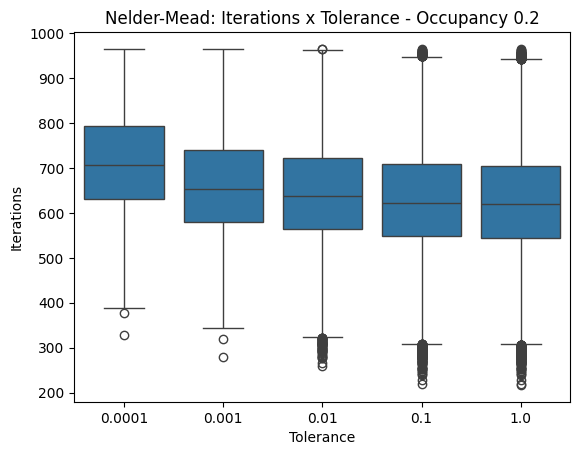

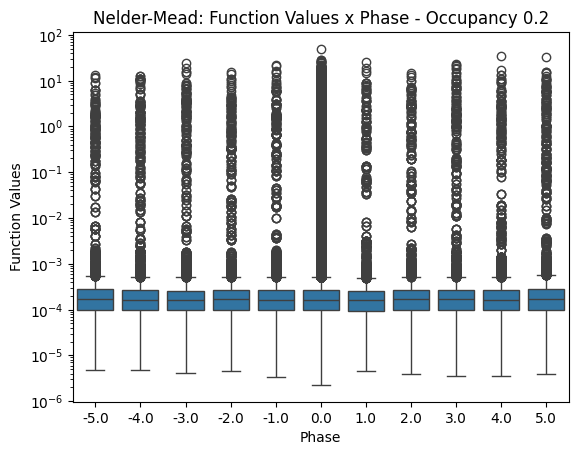

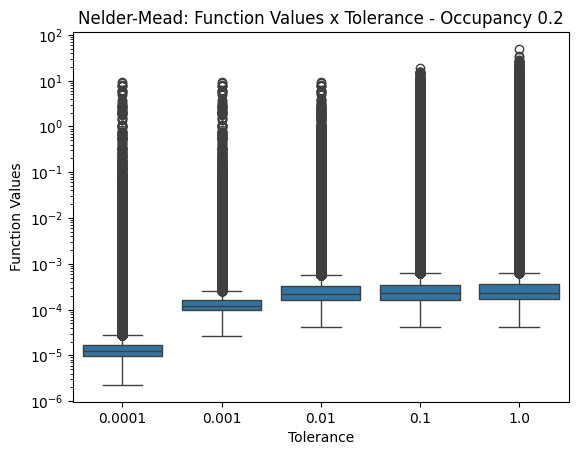

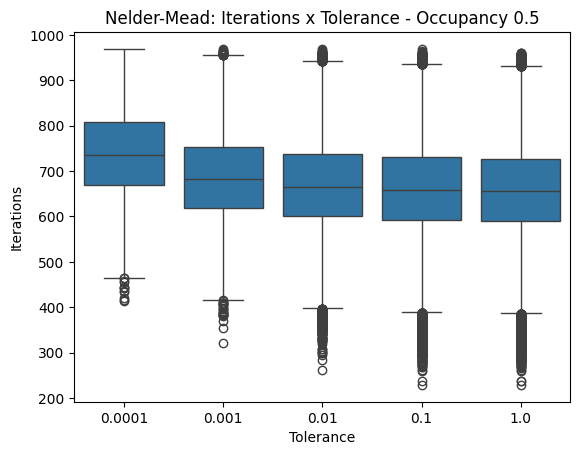

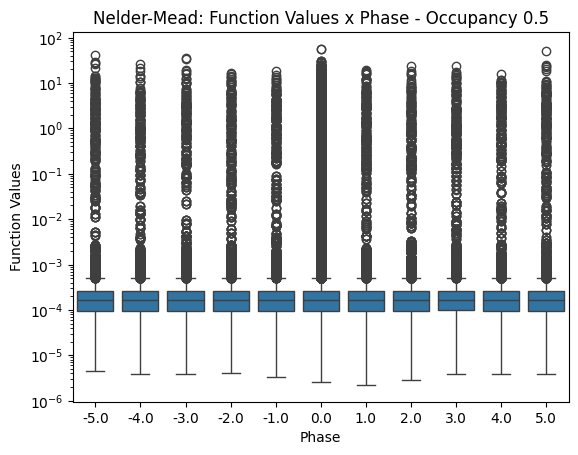

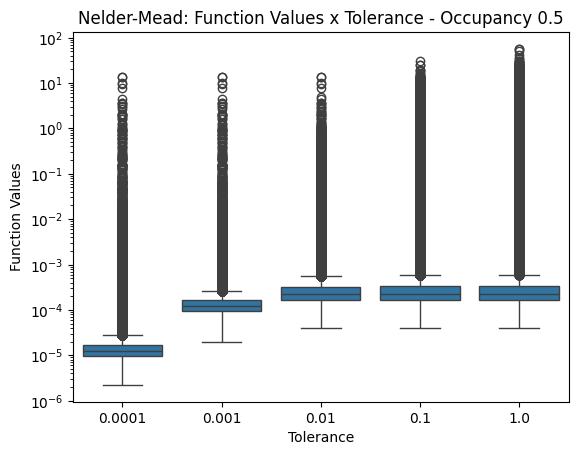

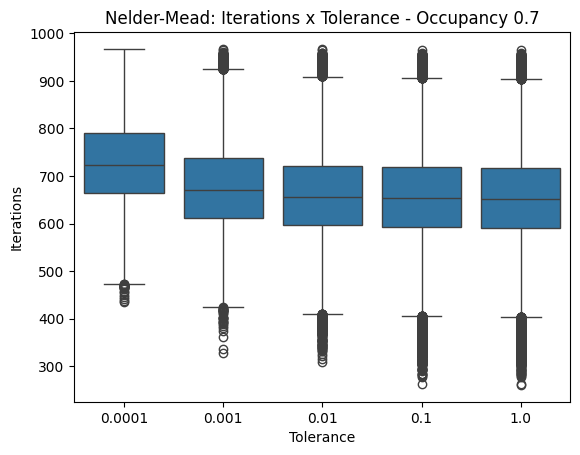

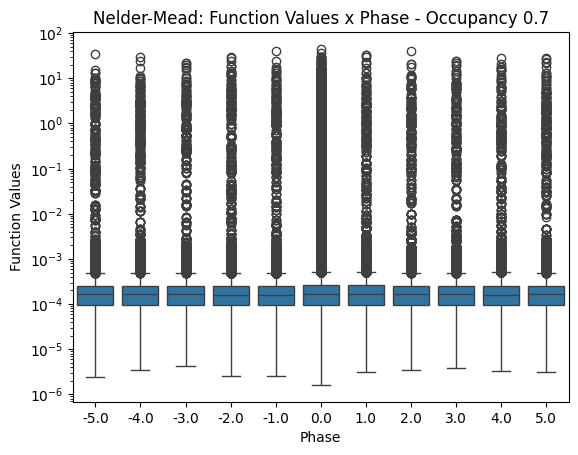

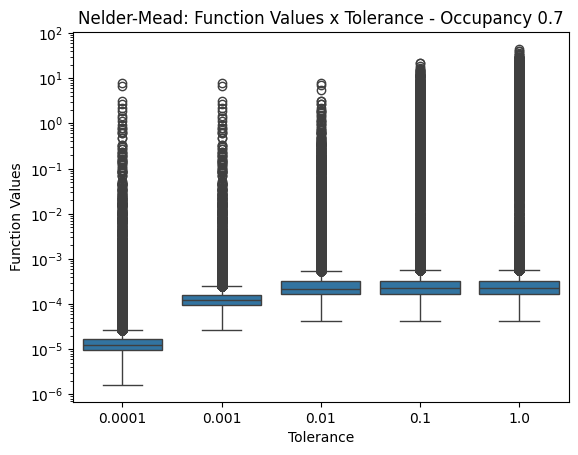

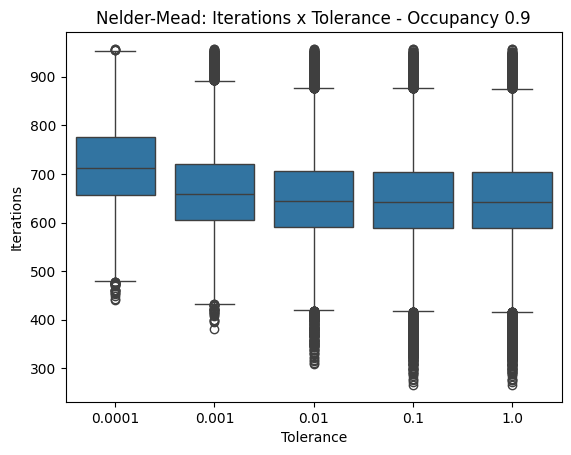

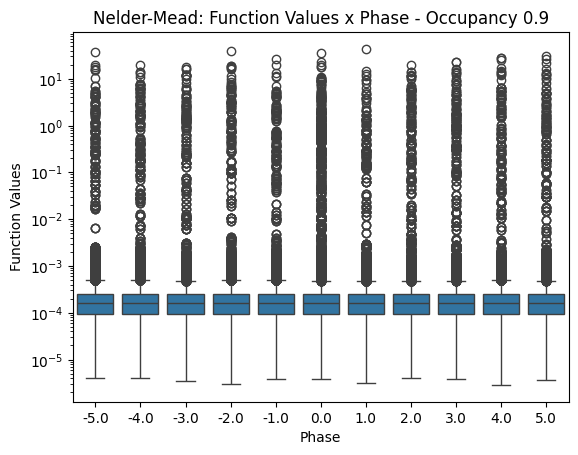

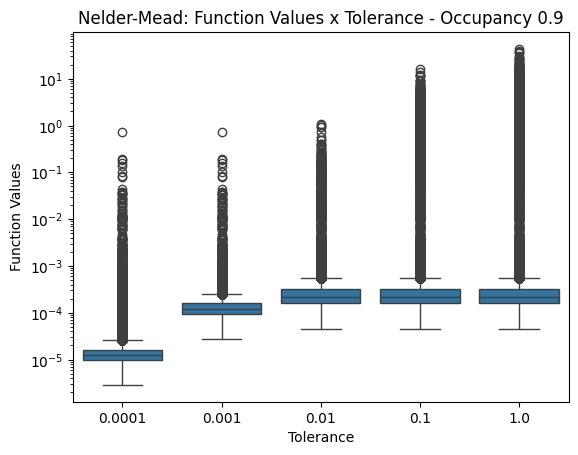

In [20]:
#Boxplot de tolerance por iterations
res = load_results()

for i in range(len(res)):
    ti = pd.DataFrame({'tolerance': res[i]['tolerance'], 'iterations': res[i]['iterations']})
    pf = pd.DataFrame({'phase': res[i]['PhaseSample(4)'], 'function_values': res[i]['function_values']})
    tf = pd.DataFrame({'tolerance': res[i]['tolerance'], 'function_values': res[i]['function_values']})
    
    sns.boxplot(x='tolerance', y='iterations', data=ti)
    plt.xlabel('Tolerance')
    plt.ylabel('Iterations')
    plt.title('Nelder-Mead: Iterations x Tolerance - Occupancy ' + occ_name[i][3:])
    plt.show()

    sns.boxplot(x='phase', y='function_values', data=pf)
    plt.xlabel('Phase')
    plt.ylabel('Function Values')
    plt.yscale('log')
    plt.title('Nelder-Mead: Function Values x Phase - Occupancy ' + occ_name[i][3:])
    plt.show()

    sns.boxplot(x='tolerance', y='function_values', data=tf)
    plt.xlabel('Tolerance')
    plt.ylabel('Function Values')
    plt.yscale('log')
    plt.title('Nelder-Mead: Function Values x Tolerance - Occupancy ' + occ_name[i][3:])
    plt.show()